In [1]:
!apt-get -qq install git-lfs
!git lfs install

!rm -rf sgis-data-manual
!git clone https://github.com/sgisgeodata/sgis-data-manual.git

%cd sgis-data-manual
!git lfs pull
%cd ..

Git LFS initialized.
Cloning into 'sgis-data-manual'...
remote: Enumerating objects: 1214, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 1214 (delta 8), reused 17 (delta 7), pack-reused 1169 (from 2)
Receiving objects: 100% (1214/1214), 295.14 MiB | 16.16 MiB/s, done.
Resolving deltas: 100% (472/472), done.
Updating files: 100% (810/810), done.
/content/sgis-data-manual
/content


In [2]:
!pip install koreanize-matplotlib

In [3]:
import geopandas as gpd  # 지리정보 파일 읽고 처리
import pandas as pd  # 표 형식 데이터 처리
import matplotlib.pyplot as plt  # 그래프, 지도 등 시각화
import koreanize_matplotlib

In [4]:
prj_dir = "/content/sgis-data-manual/공간분석 사례/Python/서울시 인구 행정동별 분석"
bord_sido = gpd.read_file(prj_dir + '/' + 'bnd_dong_11_2025_2Q.shp')

In [5]:
stat = pd.read_csv(prj_dir + '/' + '11_2023년_인구총괄(총인구).csv',
                   names=['BASE_YEAR', 'ADM_CD', 'STAT_CD', 'POP'])

In [6]:
bord_sido.head()  # 기준날짜(BASE_DATE), 행정구역 이름(ADM_NM),
                         # 행정구역 코드(ADM_CD), 지리정보(geometry)로 구성

,BASE_DATE,ADM_CD,ADM_NM,geometry
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1..."
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1..."
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1..."


In [7]:
stat.head()  # 기준년도(BASE_YEAR), 행정구역 코드(ADM_CD),
                    # 통계 코드(STAT_CD), 인구수(POP)

,BASE_YEAR,ADM_CD,STAT_CD,POP
0,2023,11,to_in_001,9384512
1,2023,11,to_in_007,4523958
2,2023,11,to_in_008,4860554
3,2023,11010,to_in_001,146179
4,2023,11010,to_in_007,69579


In [8]:
# STAT_CD 열에 있는 고유 값 확인
unique_stat_cd = stat['STAT_CD'].unique()
print(unique_stat_cd)

['to_in_001' 'to_in_007' 'to_in_008']


In [9]:
# 총인구('to_in_001') 데이터만 필터링
stat_total = stat[stat['STAT_CD'] == 'to_in_001']

In [10]:
# 필터링 후 STAT_CD 고유값 재확인
unique_stat_cd = stat_total['STAT_CD'].unique()
print(unique_stat_cd)

['to_in_001']


In [11]:
stat_total = stat_total[['ADM_CD', 'POP']]

In [12]:
print(bord_sido.dtypes)  # 경계(bord_sido) 각 열의 데이터 타입 확인

BASE_DATE      object
ADM_CD         object
ADM_NM         object
geometry     geometry
dtype: object


In [13]:
print(stat_total.dtypes)  # 통계(stat_total) 각 열의 데이터 타입 확인

ADM_CD    int64
POP       int64
dtype: object


In [14]:
stat_total['ADM_CD'] = stat_total['ADM_CD'].astype(str)  # 문자열로 변환

In [15]:
bord_sido = bord_sido.merge(stat_total, on='ADM_CD', how='left')

In [16]:
print(bord_sido.isna().sum())  # 결측값이 있는지 확인

BASE_DATE    0
ADM_CD       0
ADM_NM       0
geometry     0
POP          0
dtype: int64


In [17]:
bord_sido.head() # 병합 데이터 미리보기

,BASE_DATE,ADM_CD,ADM_NM,geometry,POP
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",8377
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",2115
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",9136
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",16475
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",7557


In [18]:
print(bord_sido['POP'].min(), bord_sido['POP'].max())  # 최소값과 최대값 확인하기

26 52789


In [19]:
bins = [10, 10000, 20000, 30000, 40000, 52000]  # 적절한 구간 지정
labels = ['10~10,000', '10,000~20,000', '20,000~30,000', '30,000~40,000', '40,000~52,000']  # 구간의 라벨

In [20]:
bord_sido['POP_BINS'] = pd.cut(bord_sido['POP'], bins=bins, labels=labels, right=False)
bord_sido.head()  # 인구 구간(‘POP_BINS’) 컬럼 추가 확인

,BASE_DATE,ADM_CD,ADM_NM,geometry,POP,POP_BINS
0,20250630,11010530,사직동,"POLYGON ((953553.932 1953335.741, 953555.211 1...",8377,"10~10,000"
1,20250630,11010540,삼청동,"POLYGON ((953844.082 1955492.177, 953858.644 1...",2115,"10~10,000"
2,20250630,11010550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",9136,"10~10,000"
3,20250630,11010560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",16475,"10,000~20,000"
4,20250630,11010570,무악동,"POLYGON ((952298.144 1953539.606, 952324.838 1...",7557,"10~10,000"


In [34]:
print(bord_sido['POP_BINS'].value_counts(dropna=False))

POP_BINS
20,000~30,000    164
10,000~20,000    156
30,000~40,000     61
10~10,000         31
40,000~52,000     13
NaN                1
Name: count, dtype: int64


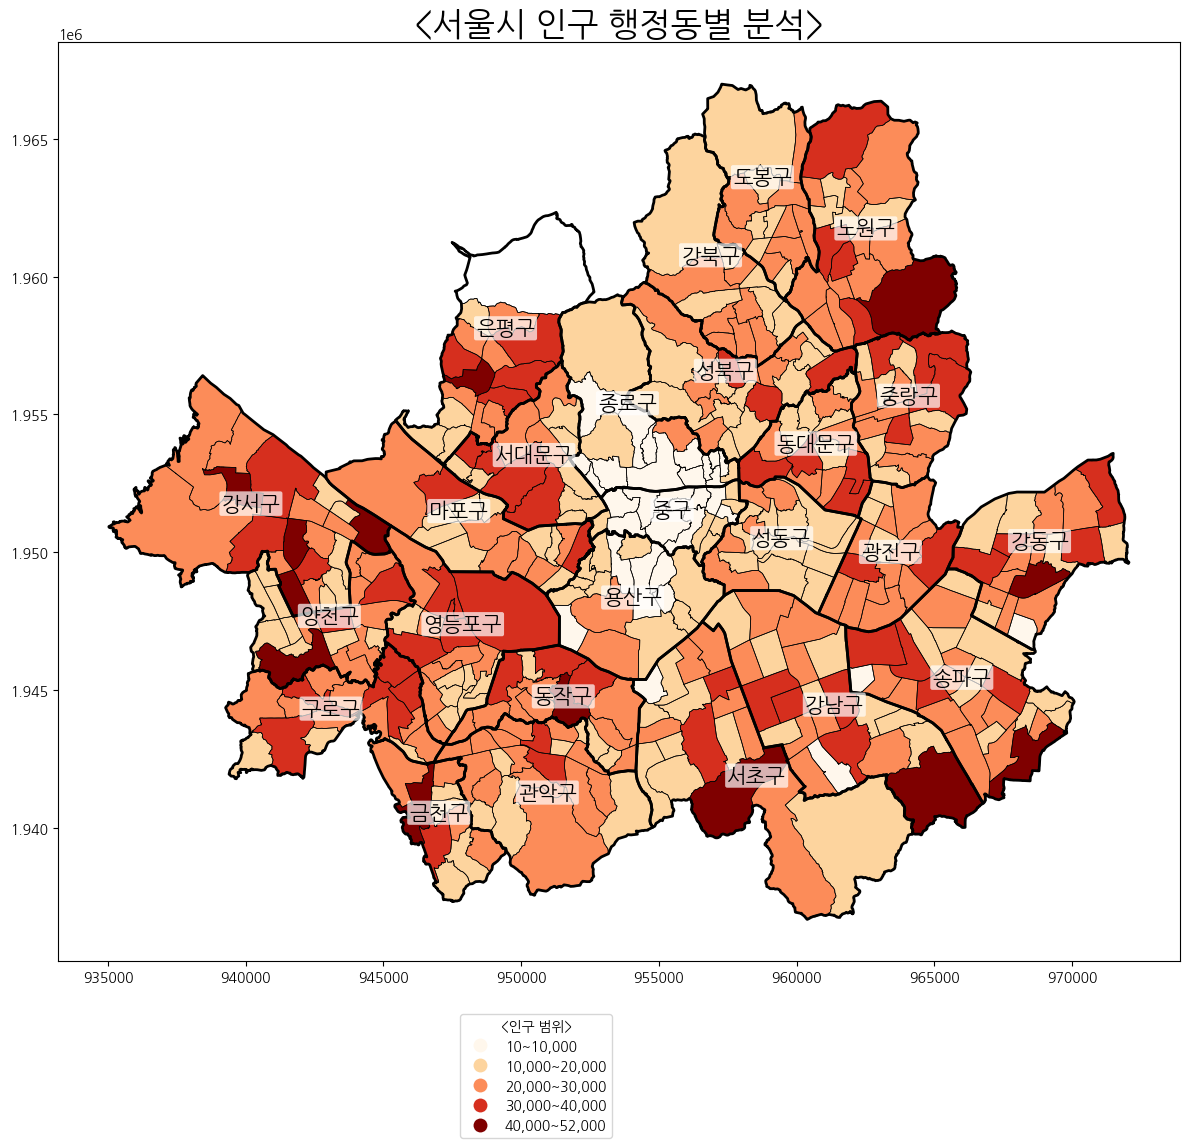

In [66]:
# 시각화 설정(그림과 축 설정)
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# 지도 시각화(‘POP_BINS’ 컬럼을 기준으로 'OrRd' 색상 맵 사용)
bord_sido.plot(column='POP_BINS', ax=ax, legend=True, cmap='OrRd')

# 서울시 행정동 경계 추가 (경계선만 보이도록 설정, 배경은 투명)
bord_sido.plot(ax=ax, color='none', edgecolor='black', linewidth=0.5)

# (추가) 서울시 시군구 경계를 추가하여 명확하게 분석하기
bord_sgg = gpd.read_file(prj_dir + '/' + 'bnd_sigungu_11_2025_2Q.shp')

bord_sgg.plot(ax=ax, color='none', edgecolor='black', linewidth=2)

bord_sgg['centroid'] = bord_sgg.geometry.centroid  # 중심점 계산
for idx, row in bord_sgg.iterrows():
    ax.text(row['centroid'].x, row['centroid'].y, row['SIGUNGU_NM'],
            fontsize=15, ha='center', color='black',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.1'))

# 범례 위치 및 제목 설정
ax.get_legend().set_bbox_to_anchor((0.5, -0.05))  # 범례 위치 조정
ax.get_legend().set_title("<인구 범위>")  # 범례 제목 설정
ax.set_title('<서울시 인구 행정동별 분석>', fontsize=24) # 지도 제목 설정

# 레이아웃 조정 및 출력
plt.tight_layout()  # 그래프 레이아웃이 겹치지 않도록 자동 조정
plt.savefig(prj_dir + '/' + '서울시 인구 행정동별 분석 지도.png')
plt.show()  # 시각화 결과 화면에 출력